# Inferring a spatial code of communication in *C. elegans*

In [Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715), we previously searched for the
ligand-receptor pairs whose cell-cell interaction scores best explain the **physical distances**
between the cells of the whole animal

This analysis relies on a single-cell dataset whose cell types were identified in a digital 3D map of cell types. This notebook links predicted cell-cell interaction scores with the physical distances computed with this 3D map b using the function `cell2cell.analysis.optimize_lr_pairs`. Additionally, it compares the result against the pairs the
paper reports, and reproduces its functional enrichment of the selected list.

The data can be found in
[LewisLabUCSD/Celegans-cell2cell](https://github.com/LewisLabUCSD/Celegans-cell2cell), which can be read with pandas
directly from the URL.

For an introduction to the method on data where the answer is known in advance, see
[Identifying a spatial code of ligand-receptor pairs](./Genetic-Algorithm-LR-Selection).

**Requirements.** `pip install cell2cell[ga]`

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.spatial
import scipy.stats
from statsmodels.stats.multitest import multipletests

import cell2cell as c2c

%matplotlib inline

## 1. The data



In [2]:
BASE = ('https://raw.githubusercontent.com/LewisLabUCSD/'
        'Celegans-cell2cell/master/data/')

We start by loading the RNAseq data, in this case corresponds to gene expression matrix of the different cell types, aggregated from the single-cell dataset.

In [3]:
celegans_rnaseq = c2c.io.load_rnaseq(
    rnaseq_file=BASE + 'RNA-Seq/Celegans_RNASeqData_Cell.xlsx',
    gene_column='symbol', drop_nangenes=True, log_transformation=False,
    format='auto', verbose=False)

We continue by loading a curated list of ligand-receptor pairs of *C. elegans*. Beyond the pair itself the table annotates each entry with an **LR function**, used in section 4, so we read it once and keep the whole thing rather than reading the file twice.

`c2c.io.load_ppi` is `c2c.io.load_table` followed by `c2c.preprocessing.preprocess_ppi_data`; splitting it in two is what lets the annotations travel with the pairs.

In [4]:
LR_COLUMNS = ('Ligand_symbol', 'Receptor_symbol')

curated = c2c.io.load_table(BASE + 'PPI-Networks/Celegans-Curated-LR-pairs.xlsx',
                            format='auto', verbose=False)

# `remove_ppi_bidirectionality` can flip a pair around, so run it here, on the table
# that still carries the annotations. Everything downstream then shares one
# orientation, and the call inside `preprocess_ppi_data` below has nothing left to do.
curated = c2c.preprocessing.remove_ppi_bidirectionality(
    curated, interaction_columns=LR_COLUMNS, verbose=False)

# The rest of what `load_ppi` does: reduce to 'A'/'B'/'score' and keep the pairs whose
# ligand and receptor are both measured.
celegans_lr = c2c.preprocessing.preprocess_ppi_data(
    ppi_data=curated, interaction_columns=LR_COLUMNS,
    rnaseq_genes=list(celegans_rnaseq.index),
    upper_letter_comparison=False, verbose=False)

Finally, we load the 3D map that was pre-annotated with cell type labels matching the RNAseq data. With this we will know the spatial location of the different cell types.

In [5]:
physical_distances = pd.read_csv(
    BASE + 'Digital-3D-Map/Celegans_Physical_Distances_Min.csv', index_col=0)

The whole data used in this analysis consists of:

In [6]:
print('expression      :', celegans_rnaseq.shape, '(genes x cells)')
print('LR pairs        :', len(celegans_lr))
print('cells in the map:', physical_distances.shape[0])

expression      : (19391, 27) (genes x cells)
LR pairs        : 245
cells in the map: 22


Pairs are carried by gene symbol throughout — the identifiers the search itself runs on — and the curated **LR function** is attached where it helps to read the result:

In [7]:
lr_functions = curated.drop_duplicates(subset=list(LR_COLUMNS)) \
                     .set_index(list(LR_COLUMNS))['LR Function']

def annotate(frame, a='A', b='B'):
    """Adds the curated LR function to a frame of pairs."""
    keys = pd.MultiIndex.from_frame(frame[[a, b]])
    return frame.assign(**{'LR function': lr_functions.reindex(keys).values})

print('curated annotations for {} pairs'.format(len(curated)))
curated[['Ligand_symbol', 'Receptor_symbol', 'LR Function']].head()

curated annotations for 245 pairs


,Ligand_symbol,Receptor_symbol,LR Function
0,arf-1.2,pld-1,Cell adhesion
1,daf-7,sma-6,TGF-B signaling
2,srp-6,F14B4.1,Wnt signaling
3,adm-2,pat-3,Cell adhesion
4,adm-2,pat-2,Cell adhesion


## 2. Using a Genetic Algorithm to search LR pairs associated with physical distance

The study reported three ways of generating an aggregate CCI score between every pair of cells:

| Score | `communication_score` | `cci_score` | Notes |
|---|---|---|---|
| Bray-Curtis | `expression_thresholding` | `bray_curtis` | the main analysis |
| LR count | `expression_thresholding` | `count` | counts active pairs |
| ICELLNET | `expression_product` | `icellnet` | expression is `log2(x + 1)` transformed first |

As introducted by [Armingol et al. (2022)](https://doi.org/10.1371/journal.pcbi.1010715), we run the Bray-Curtis score, using the same published parameters: 200 individuals, 200 generations, a 10 TPM
threshold, and runs continuing until the objective improves by less than 2.5%.

In [8]:
celegans_setup = {'communication_score': 'expression_thresholding',
                  'cci_score': 'bray_curtis',
                  'cci_type': 'undirected'}

start = time.perf_counter()
celegans_results = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},   # 10 TPM
    analysis_setup=celegans_setup,
    population_size=200,
    generations=200,
    runs=None,                 # until the objective stops improving
    inc_percentage=0.025,
    random_state=888,
)
print('finished in {:.0f} s'.format(time.perf_counter() - start))

pd.DataFrame([{'run': k, 'objective': celegans_results[k]['obj_fn'],
               'LR pairs kept': celegans_results[k]['n_selected'],
               'LR fraction' : celegans_results[k]['n_selected'] / celegans_lr.shape[0]
              }
              for k in sorted(celegans_results) if k.startswith('run')])

finished in 20 s


,run,objective,LR pairs kept,LR fraction
0,run1,0.539302,84,0.342857
1,run2,0.635369,41,0.167347
2,run3,0.644633,25,0.102041


In contrast to the [original implementation](https://github.com/LewisLabUCSD/Celegans-cell2cell/blob/master/code/genetic_algorithm.py), this new built-in function in ***cell2cell*** is much faster! Each of the ~40,000 objective evaluations per run (200 individuals x 200 generations) would otherwise have meant rebuilding the InteractionSpace each time, running for the order of mins/hours. Here, a new vectorized scorer is what brings the whole search down to seconds.

## 3. Comparing with the pairs published in the paper

The 37 pairs selected with the GA in the paper when using Bray-Curtis are in the same repository of the repo:

In [9]:
paper_pairs = pd.read_csv(BASE + 'PPI-Networks/Celegans-GA-BrayCurtis-Selected-LR-pairs.csv')

# `remove_ppi_bidirectionality` can flip a pair, so compare them as unordered
unordered = lambda a, b: frozenset((a, b))
paper_keys = {unordered(a, b) for a, b in
              paper_pairs[['Ligand_symbol', 'Receptor_symbol']].values}
our_keys = {unordered(a, b) for a, b in
            celegans_results['best_ppi_data'][['A', 'B']].values}

shared = our_keys & paper_keys
print('paper selection      : {} pairs'.format(len(paper_keys)))
print('our selection        : {} pairs'.format(len(our_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(our_keys - paper_keys)))
print('  of the paper\'s, we recovered {} ({:.0%})'
      .format(len(shared), len(shared) / len(paper_keys)))

paper selection      : 37 pairs
our selection        : 25 pairs
  also in the paper  : 19
  not in the paper   : 6
  of the paper's, we recovered 19 (51%)


### Integrating independent executions

The overlap above comes from a single execution, which understates the agreement: a genetic
algorithm returns a *local* optimum, so different seeds land on different, largely overlapping
sets, and no one of them is the answer.

The published analysis handled this by running the search many times independently, specifically 100 times, and asking which
pairs are selected **together**. `executions=N` performs multiple independent runs of the GA search and adds three
things to the result:

- `selection_frequency` — how often each pair was chosen;
- `cooccurrence` — the Jaccard index between the selection patterns of every two pairs, i.e. how
  often they are chosen alongside each other;
- `consensus_ppi_data` — the pairs of the co-occurrence cluster whose members are most consistently
  co-selected. **This is the output to use.**

For demonstration, here we run 30 independent GA searches with `executions=30`:

In [10]:
start = time.perf_counter()
consensus = c2c.analysis.optimize_lr_pairs(
    rnaseq_data=celegans_rnaseq,
    ppi_data=celegans_lr,
    reference_distances=physical_distances,
    cutoff_setup={'type': 'constant_value', 'parameter': 10},
    analysis_setup=celegans_setup,
    population_size=200, generations=200, runs=None, inc_percentage=0.025,
    executions=30,             # thirty independent searches
    random_state=888,
)
print('30 executions in {:.0f} s'.format(time.perf_counter() - start))

annotate(consensus['selection_frequency']).head(12)

30 executions in 620 s


,A,B,frequency,LR function
230,K05F1.5,dma-1,0.966667,Cell migration
60,cwn-1,mig-1,0.966667,Wnt signaling
86,mab-20,plx-2,0.966667,Cell migration
155,smp-2,plx-1,0.966667,Cell migration
112,lin-44,cfz-2,0.933333,Wnt signaling
7,let-756,ver-1,0.933333,Canonical RTK-Ras-ERK signaling
35,col-99,ddr-1,0.933333,Cell adhesion
168,wrt-5,ptc-1,0.900000,Hedgehog signaling
240,mec-5,mec-10,0.900000,Mechanosensory mechanism
227,dbl-1,sma-10,0.833333,TGF-B signaling


The co-occurrence matrix is what the consensus is built from. Clustering it separates a tight group
of pairs that keep being chosen together from a diffuse remainder.

In [11]:
sizes = {k: len(v) for k, v in consensus['consensus_clusters'].items()}
scores = {k: round(v, 3) for k, v in consensus['consensus_cluster_scores'].items()}
print('cluster sizes             :', sizes)
print('mean co-occurrence within :', scores)
print('\nconsensus selection: {} pairs'.format(len(consensus['consensus_ppi_data'])))

cluster sizes             : {np.int32(1): 79, np.int32(2): 34}
mean co-occurrence within : {np.int32(1): 0.072, np.int32(2): 0.457}

consensus selection: 34 pairs


In [12]:
consensus_keys = {unordered(a, b) for a, b in consensus['consensus_ppi_data'][['A', 'B']].values}
shared = consensus_keys & paper_keys
print('consensus selection  : {} pairs'.format(len(consensus_keys)))
print('  also in the paper  : {}'.format(len(shared)))
print('  not in the paper   : {}'.format(len(consensus_keys - paper_keys)))

annotate(consensus['consensus_ppi_data']).assign(
    in_paper=[unordered(a, b) in paper_keys
              for a, b in consensus['consensus_ppi_data'][['A', 'B']].values]) \
    .sort_values(['in_paper', 'A'], ascending=[False, True])

consensus selection  : 34 pairs
  also in the paper  : 34
  not in the paper   : 0


,A,B,score,LR function,in_paper
31,K05F1.5,dma-1,1.0,Cell migration,True
28,arg-1,lin-12,1.0,Notch signaling,True
2,cle-1,gpn-1,1.0,Cell adhesion,True
6,col-99,ddr-1,1.0,Cell adhesion,True
10,cwn-1,lin-17,1.0,Wnt signaling,True
11,cwn-1,mig-1,1.0,Wnt signaling,True
0,daf-7,sma-6,1.0,TGF-B signaling,True
29,dbl-1,sma-10,1.0,TGF-B signaling,True
30,dbl-1,lon-2,1.0,TGF-B signaling,True
9,grd-11,ptc-1,1.0,Hedgehog signaling,True


In the original algorithm, a consensus list is built by clustering the co-occurence matrix of every pair of LR pairs across all executions of the GA. The two criteria for *which* cluster to keep here is set by `cluster_selection='cooccurrence'` (the default), which ranks by mean co-occurrence among a cluster's own members, which is the property the analysis is actually after.

> **How many executions?** The clustering needs enough of them. Two pairs selected once, in the same
> execution, have a co-occurrence of 1.0 without that meaning anything, and with too few executions a
> cluster of such pairs outscores the reproducible one. Use around 30 or more (the
> reference analysis used about a hundred), or set `min_frequency` to drop the rarely-chosen pairs.
> The frequency route below is the more forgiving of the two.

#### The simpler alternative: selection frequency

Rather than asking which pairs are chosen *together*, one can just keep those chosen *often*. The
reference notebook computed this too, using the 90th percentile of the frequency distribution. It is
easier to reason about, but it cannot separate two groups of pairs that are each self-consistent yet
rarely co-selected.

In [13]:
frequency = consensus['selection_frequency']['frequency'].values

for percentile in (80, 85, 90, 95):
    mask, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=percentile)
    kept = consensus['selection_frequency'].loc[mask]
    keys = {unordered(a, b) for a, b in kept[['A', 'B']].values}
    print('{}th percentile (frequency > {:.2f}): {:>2} pairs | {:>2} in the paper, {:>2} not'
          .format(percentile, threshold, len(keys), len(keys & paper_keys),
                  len(keys - paper_keys)))

80th percentile (frequency > 0.20): 47 pairs | 36 in the paper, 11 not
85th percentile (frequency > 0.27): 36 pairs | 35 in the paper,  1 not
90th percentile (frequency > 0.47): 24 pairs | 24 in the paper,  0 not
95th percentile (frequency > 0.66): 13 pairs | 13 in the paper,  0 not


Neither route selects a pair the paper does not report, and the co-occurrence clustering recovers
the larger part of the published list, where the 90th-percentile frequency keeps a smaller and more
conservative subset of it. They are still answering different questions — the clustering keeps
*groups* of pairs that are chosen together, the frequency threshold ranks pairs individually — and
the clustering is the more demanding of the two, which is why it benefits most from more executions.
The section below closes the loop: the executions of the published analysis itself, run through this
same code, return the published list exactly.

The same steps are available on their own, for integrating results computed elsewhere:
`c2c.analysis.lr_selection_frequency`, `lr_cooccurrence`, `consensus_from_cooccurrence` and
`consensus_from_frequency`.

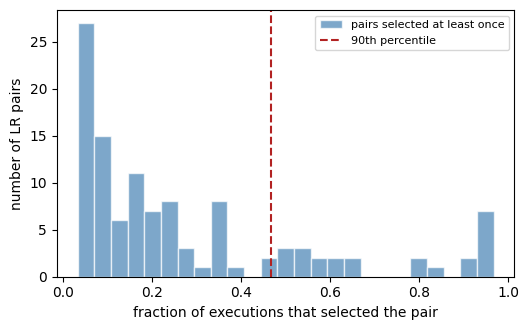

In [14]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.hist(frequency[frequency > 0], bins=25, color='steelblue', alpha=0.7,
        edgecolor='w', label='pairs selected at least once')
_, threshold = c2c.analysis.consensus_from_frequency(frequency, percentile=90)
ax.axvline(threshold, color='firebrick', ls='--', label='90th percentile')
ax.set_xlabel('fraction of executions that selected the pair')
ax.set_ylabel('number of LR pairs'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reproducing the published consensus exactly

The 100 executions behind the paper are themselves stored in the repository, one JSON per
execution, in the same shape `optimize_lr_pairs` returns. Feeding the selections *they* converged
to through the consensus implemented here returns the published list of pairs, exactly — which is
the part of the port worth checking, since it is the result the paper reports.

Note that the objective values stored next to those selections are not reproducible from them, and
this is a property of the stored files rather than of either implementation: running the original
scoring code on those same masks returns what the code here returns, to the last digit, and
disagrees with the objective stored beside the mask in most executions. Which step of the original
paired them that way is not something this notebook establishes, and it does not need to: the
selections themselves are consistent — the number of pairs each keeps matches the drop fraction
recorded with it, run after run — and they are what the published list of pairs was built from.

In [15]:
import json
import urllib.request

# One JSON per execution, holding each successive run of that execution
listing = json.loads(urllib.request.urlopen(
    'https://api.github.com/repos/LewisLabUCSD/Celegans-cell2cell/'
    'contents/data/GA-Bray-Curtis').read())

published_masks = []
for entry in sorted(listing, key=lambda e: e['name']):
    execution = json.loads(urllib.request.urlopen(BASE + 'GA-Bray-Curtis/' + entry['name']).read())
    last = max((k for k in execution if k.startswith('run')), key=lambda k: int(k[3:]))
    published_masks.append(execution[last]['ppi_data'])
published_masks = np.asarray(published_masks, dtype=int)
print('published executions: {} x {} pairs'.format(*published_masks.shape))

# The masks are positional, so they are indexed against the pairs in the order the
# curated table lists them -- which is the order `celegans_lr` holds
labels = ['{}^{}^{}'.format(a, b, i)
          for i, (a, b) in enumerate(celegans_lr[['A', 'B']].values)]
published_frequency = c2c.analysis.lr_selection_frequency(published_masks)
published_cooccurrence = c2c.analysis.lr_cooccurrence(published_masks, labels=labels)
chosen, _, _ = c2c.analysis.consensus_from_cooccurrence(
    published_cooccurrence, n_clusters=2, select='smallest',
    frequency=published_frequency, min_frequency=0.0)

chosen = set(chosen)
reproduced = {unordered(a, b) for label, (a, b)
              in zip(labels, celegans_lr[['A', 'B']].values) if label in chosen}
print('consensus from them : {} pairs'.format(len(reproduced)))
print('the paper reports   : {} pairs'.format(len(paper_keys)))
print('identical           : {}'.format(reproduced == paper_keys))

published executions: 100 x 245 pairs
consensus from them : 37 pairs
the paper reports   : 37 pairs
identical           : True


## 4. Which functions are the selected pairs enriched for?

The curated ligand-receptor table annotates every pair with an **LR function** — Wnt signalling,
cell adhesion, Hedgehog signalling, and so on. Asking which of those the search favours turns a list
of gene pairs into a statement about biology.

The paper's test, reproduced here:

1. every execution contributes its selected list;
2. for each execution, the **fraction** of its list falling in each function;
3. the background is the fraction of each function in the **full** pair list;
4. a Wilcoxon signed-rank test compares the distribution of per-execution fractions against that
   background, one-sided in each direction;
5. Benjamini-Hochberg across functions, reporting the smaller of the two adjusted values.

The test operates on the spread across executions, so **its resolution is bounded by how many there
are**: with *n* executions the smallest achievable one-sided p-value is `2**-n`. With 8 everything
floors around 0.004 and looks marginal; the 30 used here floor near `1e-9`, and the paper used about
a hundred.

In [16]:
# `functions` reuses the annotation built in section 1. The pool is what the masks
# are indexed against -- `selection_frequency` is sorted, so pairing that with the
# masks positionally would misalign them.
pool = consensus['pool']
functions = annotate(pool)['LR function']
print('pairs with a curated function: {} of {}'.format(functions.notna().sum(), len(functions)))

masks = np.asarray(consensus['selection_masks'])
counts = pd.DataFrame(masks.T, index=functions.values).groupby(level=0).sum()
fractions = counts / counts.sum()                      # function x execution
background = functions.value_counts(normalize=True)    # the full list
print('{} functions, {} executions'.format(*fractions.shape))

pairs with a curated function: 245 of 245
20 functions, 30 executions


In [17]:
rows = []
for function, row in fractions.iterrows():
    difference = row.values - background[function]
    if np.any(difference != 0):
        greater = scipy.stats.wilcoxon(difference, alternative='greater')[1]
        less = scipy.stats.wilcoxon(difference, alternative='less')[1]
    else:
        greater = less = 1.0
    rows.append({'LR Function': function,
                 'n_pairs': int((functions == function).sum()),
                 'greater_p': greater, 'less_p': less,
                 'fold_change': row.median() / background[function]})

enrichment = pd.DataFrame(rows).set_index('LR Function')
for side in ('greater', 'less'):
    enrichment[side + '_q'] = multipletests(enrichment[side + '_p'].values,
                                            alpha=0.01, method='fdr_bh')[1]
enrichment['adj_p'] = enrichment[['greater_q', 'less_q']].min(axis=1)
enrichment['direction'] = np.where(enrichment['fold_change'] > 1, 'enriched', 'depleted')
enrichment = enrichment.sort_values('fold_change', ascending=False)
enrichment[['n_pairs', 'fold_change', 'adj_p', 'direction']].round(4)

,n_pairs,fold_change,adj_p,direction
LR Function,,,,
Hedgehog signaling,6,2.9167,0.0000,enriched
Mechanosensory mechanism,6,2.1506,0.0000,enriched
Cell migration,27,1.5637,0.0000,enriched
Stress response,5,1.2747,0.5687,enriched
Canonical RTK-Ras-ERK signaling,8,1.1779,0.0675,enriched
Wnt signaling,45,0.9991,0.8386,depleted
Notch signaling,24,0.9015,0.2527,depleted
Cell adhesion,46,0.7989,0.0002,depleted
TGF-B signaling,19,0.7714,0.0356,depleted


The figure the paper reports: one box per function over the per-execution fold changes, on a
`log10(FC + 1)` scale so that a fold change of 1 — no enrichment — sits at `log10(2) ≈ 0.30`.

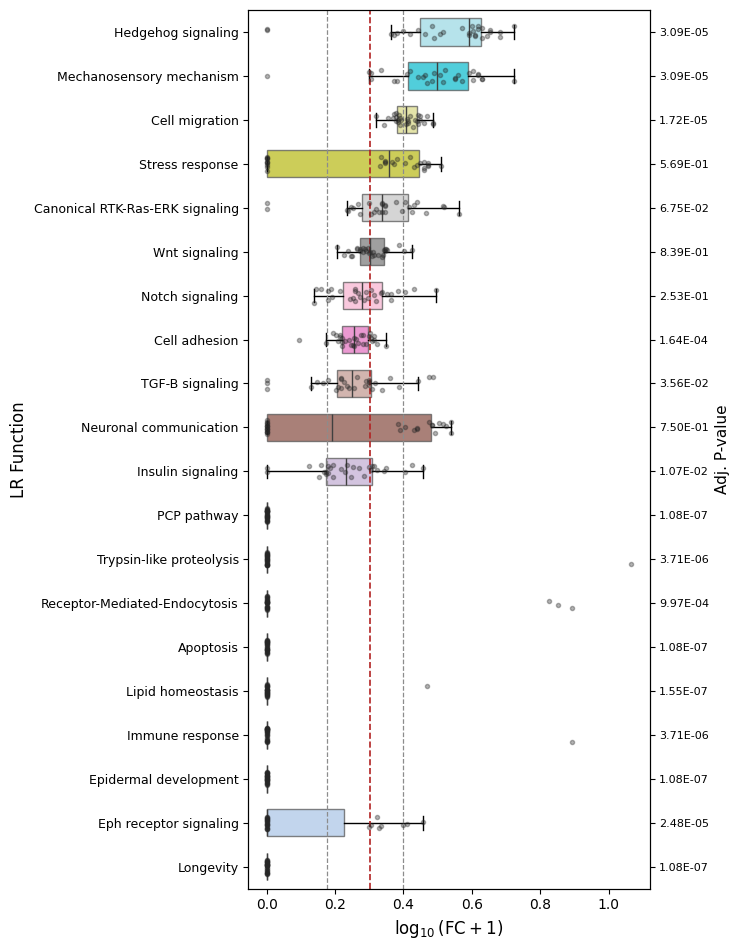

In [18]:
fold_changes = fractions.div(background, axis=0)
plot_order = enrichment.index[::-1]
values = [np.log10(fold_changes.loc[f].values + 1) for f in plot_order]

fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(plot_order) + 1.2))
colours = plt.get_cmap('tab20')(np.linspace(0, 1, len(plot_order)))
bp = ax.boxplot(values, vert=False, patch_artist=True, widths=0.62,
                medianprops=dict(color='0.25'), flierprops=dict(marker=''))
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour); patch.set_alpha(0.75); patch.set_edgecolor('0.35')

rng_jitter = np.random.default_rng(0)
for i, v in enumerate(values, start=1):
    ax.scatter(v, i + rng_jitter.uniform(-0.16, 0.16, len(v)), s=9,
               color='0.15', alpha=0.35, zorder=3)

ax.axvline(np.log10(2), color='firebrick', ls='--', lw=1.2)          # fold change of 1
for fc in (0.5, 1.5):
    ax.axvline(np.log10(fc + 1), color='0.55', ls='--', lw=0.9)
ax.set_yticks(range(1, len(plot_order) + 1)); ax.set_yticklabels(plot_order, fontsize=9)
ax.set_xlabel('$\\log_{10}(\\mathrm{FC}+1)$', fontsize=12)
ax.set_ylabel('LR Function', fontsize=12)

right = ax.twinx()
right.set_ylim(ax.get_ylim()); right.set_yticks(range(1, len(plot_order) + 1))
right.set_yticklabels(['{:.2E}'.format(enrichment.loc[f, 'adj_p']) for f in plot_order], fontsize=8)
right.set_ylabel('Adj. P-value', fontsize=11)
plt.tight_layout(); plt.show()

The red line is no enrichment; the grey lines mark fold changes of 0.5 and 1.5. Functions whose
boxes sit entirely at 0 were never chosen by any execution — strongly *depleted*, and the Wilcoxon
reports them as such rather than as absent evidence.

Two things to keep in mind when reading this:

- **It is conditioned on the curated annotation.** A function with one or two pairs in the whole
  list cannot show a stable fold change, and its p-value reflects consistency across executions
  rather than strength of evidence about biology.
- **Depletion is a real result here**, not a failure to detect. A function that the search reliably
  drops is one whose pairs do not help explain physical distance — which is informative given that
  the background is the curated list someone assembled as plausible.

## Notes

- **`pygad` is not `pyevolve`**, the seeds differ, and the published set is one run of many, so the
  numbers will not match exactly. The reproducible core is what should agree, and does.
- **No multiprocessing.** The original distributed independent runs across cores; the vectorized
  objective makes one run fast enough that it is not needed.
- **`selection_masks` is indexed against `results['pool']`**, not against `selection_frequency`,
  which is sorted by frequency for reading. Pairing the sorted frame with the masks positionally is
  a silent misalignment.